<a href="https://colab.research.google.com/github/SaniyaIrfan1113/MachineLearningProjects/blob/main/09_K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

Upload Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving studentscores.csv to studentscores.csv


Read Dataset

In [ ]:
dataset = pd.read_csv("studentscores.csv")

In [ ]:
dataset.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


Understand Dataset

In [ ]:
dataset.shape

(25, 2)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [ ]:
dataset.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [ ]:
dataset.isnull().sum()

,0
Hours,0
Scores,0


Select Features

In [ ]:
X = dataset.iloc[:, [0,1]].values

In [ ]:
print(X[:5])

[[ 2.5 21. ]
 [ 5.1 47. ]
 [ 3.2 27. ]
 [ 8.5 75. ]
 [ 3.5 30. ]]


Find the Best Number of Clusters (Elbow Method)

In [ ]:
wcss = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=0
    )

    model.fit(X)
    wcss.append(model.inertia_)

In [ ]:
wcss = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        init="k-means++",
        random_state=0
    )

    model.fit(X)
    wcss.append(model.inertia_)

Create K-Means Model

In [ ]:
model = KMeans(
    n_clusters=3,
    init="k-means++",
    random_state=0
)

Train Model

In [ ]:
model.fit(X)

KMeans(n_clusters=3, random_state=0)

Predict Cluster for Each Student

In [ ]:
y_cluster = model.predict(X)

In [ ]:
print(y_cluster)

[2 0 2 1 2 2 1 0 1 2 1 0 0 0 2 1 2 2 1 1 2 0 2 1 1]


Cluster Centers

In [ ]:
print(model.cluster_centers_)

[[ 4.85       51.        ]
 [ 7.86666667 80.22222222]
 [ 2.54       25.9       ]]


Visualize Clusters

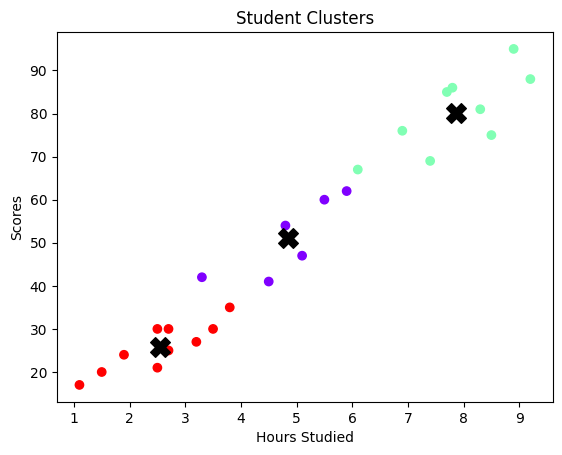

In [ ]:
plt.scatter(
    X[:,0],
    X[:,1],
    c=y_cluster,
    cmap="rainbow"
)

plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[:,1],
    c="black",
    s=200,
    marker="X"
)

plt.title("Student Clusters")
plt.xlabel("Hours Studied")
plt.ylabel("Scores")
plt.show()

Predict Cluster for a New Student

In [ ]:
new_student = [[6, 60]]

prediction = model.predict(new_student)

print(prediction)

[0]


Save Model

In [ ]:
import joblib

joblib.dump(model, "kmeans_model.pkl")

['kmeans_model.pkl']

In [ ]:
loaded_model = joblib.load("kmeans_model.pkl")